### Random Forest Model made with PyTorch
Relevant Statistics:

In [1]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


In [2]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [3]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
# X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
# Create custom class weights 

custom_weights = []
for col in target_columns:
    # Calculate weights for each label
    positives = y_train_int[:, target_columns.index(col)].sum()
    negatives = len(y_train_int) - positives
    # If positives are very few, increase their weight
    weight = {0: 1, 1: max(10, int(negatives / max(positives, 1)))}
    custom_weights.append(weight)


In [7]:
# Create Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Convert targets to integers
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Create custom class weights 
custom_weights = []
for col in target_columns:
    # Calculate weights for each label
    positives = y_train_int[:, target_columns.index(col)].sum()
    negatives = len(y_train_int) - positives
    # If positives are very few, increase their weight
    weight = {0: 1, 1: max(10, int(negatives / max(positives, 1)))}
    custom_weights.append(weight)


In [9]:
# Train a separate RandomForestClassifier for each target column
rf_models = []
for i, col in enumerate(target_columns):
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=custom_weights[i]
    )
    clf.fit(X_train_scaled, y_train_int[:, i])
    rf_models.append(clf)

# Predict for each classifier
y_pred = np.zeros_like(y_test_int)
for i, clf in enumerate(rf_models):
    y_pred[:, i] = clf.predict(X_test_scaled)

In [14]:

# Evaluate the predictions for each category
metrics = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_test_int[:, i], y_pred[:, i])
    prec = precision_score(y_test_int[:, i], y_pred[:, i], zero_division=0)
    rec = recall_score(y_test_int[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_test_int[:, i], y_pred[:, i], zero_division=0)
    metrics.append({
        'Category': col,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

           Category  Accuracy  Precision    Recall        F1
0               any  0.816744   0.829864  0.694697  0.756289
1          epidural  0.985116   0.000000  0.000000  0.000000
2  intraparenchymal  0.760620   0.532258  0.288750  0.374392
3  intraventricular  0.815194   0.393939  0.115865  0.179063
4      subarachnoid  0.803411   0.441489  0.135621  0.207500
5          subdural  0.809922   0.418079  0.126712  0.194481


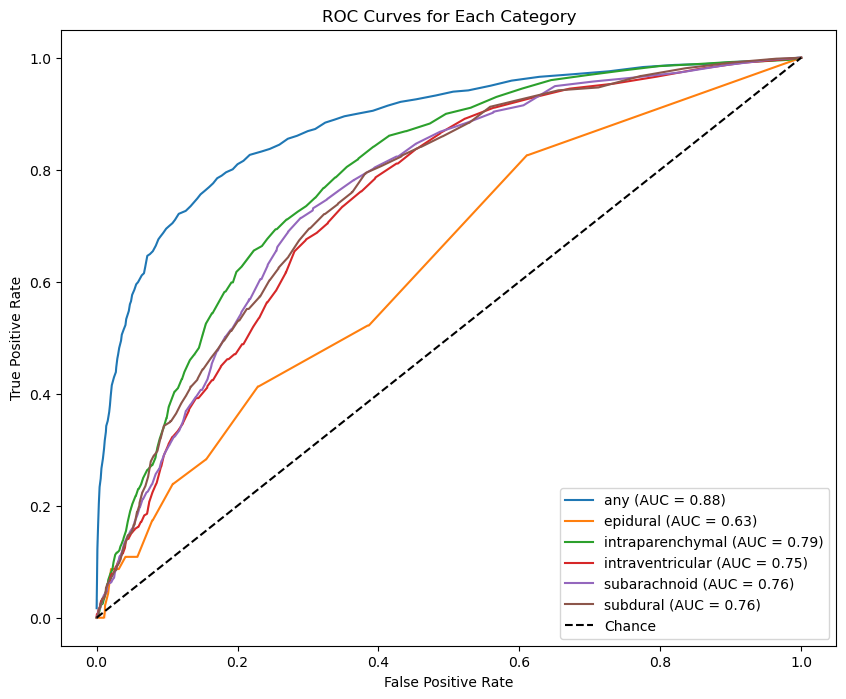

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
for i, col in enumerate(target_columns):
    # Get predicted probabilities for label i
    y_score = rf_models[i].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_int[:, i], y_score)
    roc_auc = auc(fpr, tpr)
    sns.lineplot(x=fpr, y=tpr, label=f'{col} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Category')
plt.legend(loc='lower right')
plt.show()